# Feature analysis

Everything below runs on the **training split only**. The audit in `01_eda.ipynb` described
properties of the file and could use all rows; from here on every decision — where to trim, which
features to look at, what to transform — is made after seeing the data, so the holdout has to stay
unopened or those decisions leak into the final estimate (data snooping).

The holdout is scored once, at the end of the project.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

from src.config import DATA_5YEAR_PATH, TARGET_COL
from src.data import split_holdout

X_train, X_holdout, y_train, y_holdout = split_holdout(DATA_5YEAR_PATH)

# Both should sit at ~0.070. This is the only check that catches a forgotten stratify=.
print(y_train.mean(), y_holdout.mean())

0.0697515386368817 0.06971975393028025


## 1. Per-feature separability

Choosing which features to plot needs a criterion, not intuition. `roc_auc_score` takes any vector
of scores, so a raw feature can be fed to it directly: the result says how well that single
coefficient, used as a risk score on its own, orders companies.

The scale is symmetric around 0.5, so `abs(auc - 0.5)` measures the strength of the relationship
and the raw value keeps its direction. ROC-AUC is used here as a **separability measure**, not as a
project metric — for that it is unsuitable at a 7% positive rate, which is why PR-AUC is the metric
of record.

Missing values are masked per column, so each score is computed on the rows where that feature
exists. Features with heavy missingness are therefore measured on a different subset than the rest,
and their numbers are not strictly comparable.

In [2]:
raw_auc = {}

for feature in X_train.columns:
    # Per-column mask: a row missing Attr37 is still usable when scoring Attr9.
    # The same mask has to be applied to the labels, or values and labels drift apart.
    mask = X_train[feature].notna()
    raw_auc[feature] = roc_auc_score(y_train[mask], X_train.loc[mask, feature])

auc = pd.Series(raw_auc)
summary = pd.DataFrame({"auc": auc, "strength": (auc - 0.5).abs()})
print(summary.sort_values("strength", ascending=False).head(30))

             auc  strength
Attr26  0.201943  0.298057
Attr16  0.203459  0.296541
Attr39  0.210047  0.289953
Attr45  0.215880  0.284120
Attr13  0.216099  0.283901
Attr35  0.221219  0.278781
Attr12  0.224858  0.275142
Attr23  0.225495  0.274505
Attr19  0.226856  0.273144
Attr31  0.229133  0.270867
Attr1   0.235040  0.264960
Attr18  0.236626  0.263374
Attr14  0.236652  0.263348
Attr7   0.236704  0.263296
Attr42  0.238659  0.261341
Attr25  0.239235  0.260765
Attr46  0.240040  0.259960
Attr11  0.246287  0.253713
Attr22  0.247101  0.252899
Attr55  0.248382  0.251618
Attr21  0.259671  0.240329
Attr4   0.266504  0.233496
Attr8   0.268329  0.231671
Attr38  0.269826  0.230174
Attr17  0.272819  0.227181
Attr56  0.274668  0.225332
Attr10  0.275620  0.224380
Attr54  0.276082  0.223918
Attr27  0.276983  0.223017
Attr2   0.720220  0.220220


**What the ranking says.**

Sixteen of the top twenty-five are profitability ratios — profit of one definition or another over
assets, liabilities or sales. All of them score *below* 0.5 (0.20–0.24), meaning the relationship
runs the expected way: lower profitability, higher risk. `Attr2` (total liabilities / total assets)
is the only strong feature in the other direction at 0.720 — more leverage, higher risk. Both
directions match economic sense, which is the sanity check that the labels and the masking are not
inverted somewhere.

Those sixteen are not sixteen signals. The clustermap in section 7 puts them in one dense block, so this is
**one dominant factor — profitability — measured sixteen nearly interchangeable ways**. Some of the
pairs correlate at 0.999.

Read as a statement about the problem: a year before the event, future bankrupts differ from
survivors mainly by being unprofitable, not by being illiquid — the strongest liquidity ratio
(`Attr46`, 0.260) sits below the profitability block. Plausible for a one-year horizon: sustained
losses have accumulated while a cash squeeze may not have surfaced yet. A shorter horizon would
likely reverse this, but the other horizons live in separate files and are out of scope here.

**Altman Z′.** Four of the five rank in the upper third: `Attr7` (0.263), `Attr8` (0.232), `Attr6`
(0.220), `Attr3` (0.216). The fifth, `Attr9` (asset turnover), is effectively flat at 0.031. So the
1983 feature set holds up but does not lead — more direct profitability measures beat it. `Attr9`
carried the lowest weight in the original formula, so its failure does not sink the baseline, but
it is worth noting: turnover depends heavily on industry, and industry is not encoded in this
dataset. Section 4 shows the feature is not uninformative, only non-monotone.

## 2. Missingness as a signal

The audit established that a missing `Attr37` encodes a financial state — no long-term debt, hence
a division by zero — rather than an unrecorded value. The same trick that ranks features can score
the *fact* of a missing value: pass the boolean mask as the score instead of the values.

In [3]:
# The flag is a separate score, not a replacement for the column: the frame is untouched.
print("Attr37 isna:    ", roc_auc_score(y_train, X_train["Attr37"].isna()))
print("Attr59 == 0:    ", roc_auc_score(y_train, X_train["Attr59"] == 0))
print("Attr27 isna:    ", roc_auc_score(y_train, X_train["Attr27"].isna()))

Attr37 isna:     0.5457632452638002
Attr59 == 0:     0.5441292583356956
Attr27 isna:     0.6265993532919172


`Attr37` missing and `Attr59 == 0` agree on 99.9% of rows (established in the audit) and score
almost identically here, which is the consistency check. `Attr27` — profit on operating activities
over financial expenses — is the interesting one: its missingness means no interest is being paid
at all.

In [4]:
s = X_train["Attr27"].dropna()
print(s.describe())
print(s.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.96, 0.97, 0.98, 0.99]))
print("near zero:", (s.abs() < 0.01).mean())

count      4087.000000
mean        448.923796
std       11224.874578
min     -158130.000000
25%           0.073977
50%           0.966850
75%           4.192000
max      565940.000000
Name: Attr27, dtype: float64
0.01     -81.885640
0.05      -4.217450
0.25       0.073977
0.50       0.966850
0.75       4.192000
0.95     114.180000
0.96     180.031200
0.97     394.193600
0.98    1008.908000
0.99    5259.276000
Name: Attr27, dtype: float64
near zero: 0.07438218742353805


In [5]:
a27 = X_train["Attr27"].isna()
a37 = X_train["Attr37"].isna()

print(pd.crosstab(a27, a37, rownames=["Attr27 NaN"], colnames=["Attr37 NaN"]))
print("\nshare of Attr27-NaN rows that are also Attr37-NaN:", a37[a27].mean())

Attr37 NaN  False  True 
Attr27 NaN              
False        2385   1702
True           96    204

share of Attr27-NaN rows that are also Attr37-NaN: 0.68


In [6]:
# y is 0/1, so mean() over a subset is the bankruptcy rate in that subset.
print("long-term debt but no interest paid:", y_train[a27 & ~a37].mean())
print("no debt at all:                     ", y_train[a27 & a37].mean())
print("interest paid:                      ", y_train[~a27].mean())

long-term debt but no interest paid: 0.4791666666666667
no debt at all:                      0.23039215686274508
interest paid:                       0.05211646684609738


**A missing `Attr27` splits into two very different groups.**

The overlap with `Attr37` is 68% — related but not nested, so the two flags are not the same state.
That leaves 96 rows where long-term debt exists on the balance sheet but no interest is being paid.
Their bankruptcy rate is **47.9%**, against 23.0% for companies with no debt at all and 5.2% for
everyone else. The base rate is 7.0%.

A plausible reading is an interest-free loan from an owner or related party, or payments that have
stopped being serviced. Either way it is not a normal financing arrangement.

**Why the ranking missed it.** ROC-AUC on a binary flag is dominated by ties. 213 of the 306
positives sit on the same side of the flag as 3874 negatives, and every one of those pairs scores
0.5. The metric asks how well the *whole* sample is ordered; a concentrated effect in a small
subgroup barely moves it. Numerically: `Attr27`-missing and `Attr21`-missing (section 2.2) both score 0.627
despite subgroup rates of 31% and 97.5% — for a binary flag the AUC mostly reflects how many
positives the flag covers, not how pure the flagged group is. precision@top-k, the project's second
metric, is far more sensitive to exactly this shape.

**Two caveats.** The group is 96 rows with 46 positives, so the 47.9% carries a confidence interval
of roughly ±10 points and only ~30 such companies will land in the holdout. And it was found by
trying combinations of missingness flags — the more combinations checked, the higher the chance of
landing on a spurious one. It goes forward as a CV candidate, not as an established fact.

### 2.1 Which columns deserve an indicator

`SimpleImputer(add_indicator=True)` builds a flag for every column that has any missing value at
all. With 49 such columns that turns 64 features into 113 — a near-doubling of dimensionality on
4387 rows and 306 positives, most of it from columns missing a handful of values, where the flag
cannot carry information but can still be fitted to noise.

The threshold used below is **1% of rows** (~44 values), fixed before looking at the strength of any
flag: selecting indicators by their correlation with the target would be selection on the outcome.

In [7]:
na = X_train.isna().sum()
print(na[na > 0].sort_values(ascending=False))

Attr37    1906
Attr27     300
Attr60     199
Attr45     199
Attr24      99
Attr28      84
Attr64      84
Attr53      84
Attr54      84
Attr21      80
Attr41      59
Attr32      34
Attr52      25
Attr47      25
Attr33      18
Attr12      18
Attr4       18
Attr63      18
Attr46      18
Attr40      18
Attr50      15
Attr26      15
Attr16      15
Attr17      15
Attr34      15
Attr8       15
Attr61      13
Attr5        8
Attr15       5
Attr3        3
Attr1        3
Attr7        3
Attr14       3
Attr38       3
Attr18       3
Attr11       3
Attr10       3
Attr2        3
Attr6        3
Attr25       3
Attr22       3
Attr51       3
Attr36       3
Attr35       3
Attr29       3
Attr48       3
Attr59       2
Attr57       2
Attr9        1
dtype: int64


Equal counts are not a coincidence: missing values arrive in blocks driven by one raw quantity in
the denominator. Two blocks are checked below — `Attr45`/`Attr60` divide by inventory,
`Attr28`/`Attr53`/`Attr54`/`Attr64` divide by fixed assets.

In [8]:
a60 = X_train["Attr60"].isna()
a45 = X_train["Attr45"].isna()
print(pd.crosstab(a60, a45, rownames=["Attr60 NaN"], colnames=["Attr45 NaN"]))

Attr45 NaN  False  True 
Attr60 NaN              
False        4188      0
True            0    199


In [9]:
block = ["Attr28", "Attr53", "Attr54", "Attr64"]
na_block = X_train[block].isna()
print(na_block.sum())
# nunique per row is 1 when all four masks agree on that row; max 1 means they always agree.
print("distinct values per row (max):", na_block.nunique(axis=1).max())

Attr28    84
Attr53    84
Attr54    84
Attr64    84
dtype: int64
distinct values per row (max): 1


**Seven indicators, not forty-nine.** The 1% threshold leaves 11 columns; the inventory pair
collapses to one and the fixed-assets block of four collapses to one, giving 7. That is 71 features
instead of 113.

| indicator | rows | state it encodes |
|---|---|---|
| `Attr37` | 1906 | no long-term liabilities |
| `Attr27` | 300 | no interest paid |
| `Attr45`/`Attr60` | 199 | no inventory |
| `Attr24` | 99 | no three-year profit figure |
| `Attr28`/`53`/`54`/`64` | 84 | no fixed assets |
| `Attr21` | 80 | no prior-year sales |
| `Attr41` | 59 | operating profit plus depreciation is zero |

They fall into three kinds of information: absence of debt financing (`Attr37`, `Attr27`,
`Attr41`), asset structure (no inventory, no fixed assets — effectively an industry proxy, since
services and manufacturing differ here), and reporting history (`Attr21`, `Attr24`). Missingness in
this dataset is not noise; it is a second, coarser description of the company.

`SimpleImputer(add_indicator=True)` cannot select columns, so this needs a `ColumnTransformer` with
two groups: impute-with-indicator for these seven, impute-only for the rest.

The `has_no_long_term_debt` candidate raised during the audit is now redundant — the `Attr37` indicator encodes
the same state and appears automatically.

### 2.2 `Attr21` missing — a flag that is too good

`Attr21` = sales(n) / sales(n−1), so a missing value means zero sales in the *previous* year. The
ARFF filter documented in `01_eda.ipynb` (`not ismissing(ATT20)`) removed companies with zero sales
in the *current* year, but said nothing about the year before, so these rows survived.

In [10]:
a21 = X_train["Attr21"].isna()
a24 = X_train["Attr24"].isna()

print(pd.crosstab(a21, a24, rownames=["Attr21 NaN"], colnames=["Attr24 NaN"]))
print("\nbankruptcy rate, Attr21 missing:", y_train[a21].mean())
print("bankruptcy rate, Attr24 missing:", y_train[a24].mean())
print("flag as a score, ROC-AUC:       ", roc_auc_score(y_train, a21))

Attr24 NaN  False  True 
Attr21 NaN              
False        4209     98
True           79      1

bankruptcy rate, Attr21 missing: 0.975
bankruptcy rate, Attr24 missing: 0.010101010101010102
flag as a score, ROC-AUC:        0.6272059424112698


78 of 80 rows are bankrupt. That is a quarter of all positives in the training split concentrated in
1.8% of the rows, at a base rate of 7.0% — a rate that high is a reason to suspect the data, not to
celebrate the feature.

The two flags are also close to mutually exclusive (overlap of 1 row where ~1.8 would be expected by
chance), so "short reporting history" is not the shared mechanism and `Attr24` stays a separate
indicator.

In [11]:
sub = X_train[a21]

# Current-year sales are present (Attr9, Attr20), so these are not empty shells.
print(sub[["Attr9", "Attr20", "Attr29", "Attr55"]].describe())

# But are they documented as well as the rest of the sample?
print("\nmissingness rate, flagged rows vs the rest:")
comparison = pd.DataFrame(
    {"flagged": sub.isna().mean(), "rest": X_train[~a21].isna().mean()}
)
print(comparison.sort_values("flagged", ascending=False).head(10))

           Attr9       Attr20     Attr29        Attr55
count  80.000000    80.000000  79.000000     80.000000
mean    2.382206    65.392791   3.203601  -1384.108005
std     2.211989   186.935776   0.890587   5210.614675
min     0.010746     0.000000   0.685740 -35965.000000
25%     0.925015     5.636425   2.571100  -1163.450000
50%     1.666150    24.004000   3.168800    -45.660000
75%     2.996525    63.216250   3.923000    183.810000
max     9.633600  1643.500000   5.645200   4550.000000

missingness rate, flagged rows vs the rest:
        flagged      rest
Attr21   1.0000  0.000000
Attr37   0.6250  0.430926
Attr45   0.1375  0.043650
Attr60   0.1375  0.043650
Attr54   0.1250  0.017181
Attr28   0.1250  0.017181
Attr27   0.1250  0.067332
Attr53   0.1250  0.017181
Attr64   0.1250  0.017181
Attr61   0.0375  0.002322


**What the 80 rows look like.** Current-year sales are there and the size distribution is ordinary,
so these are real filings rather than empty records. But working capital is negative for most of
them (median −45.7, lower quartile −1163), and every column at the top of the missingness
comparison is missing more often here than in the rest of the sample — `Attr37` 62.5% vs 43%, the fixed-assets block 12.5% vs 1.7%, `Attr27` 12.5% vs
6.7%.

Two readings fit, and the data cannot separate them:

- **Real signal.** A company with no revenue last year, negative working capital and gaps in its
  filing is a company in trouble. Everything is consistent.
- **Leakage through data collection.** Companies that are failing stop filing properly. The
  prior-year figure is absent because the record was never submitted, not because sales were zero —
  in which case the flag is a trace of the outcome rather than a predictor of it.

The uniformly elevated missingness across all columns leans towards the second. Without metadata on
how the dataset was assembled there is no way to decide.

**Decision: the `Attr21` indicator stays out of the model.** If it is leakage it inflates both CV
and holdout — the contamination is inside the data, not across the split — so no metric would reveal
the problem. This goes to README Limitations alongside the near-duplicate risk recorded in the audit. Worth
running once with and without the flag, not to pick the better number but to quantify how much of
the metric rests on this subgroup.

## 3. Priority features

Seven features, drawn from three sources: hypotheses left open by the audit (`Attr37`, `Attr59`),
the Altman Z′ set, and the ranking above. The ranking alone would not do — sixteen of its top
twenty-five measure profitability in one form or another, so taking the top seven would mean
looking at the same picture seven times. One representative per economic family instead.

In [12]:
# Attr26 profitability, Attr46 quick ratio, Attr2 leverage, Attr21 sales growth,
# Attr55 firm size (absolute), Attr9 Altman X5, Attr59 long-term debt structure.
PRIORITY_FEATURES = ["Attr26", "Attr46", "Attr2", "Attr21", "Attr55", "Attr9", "Attr59"]

## 4. Distributions by class

Rows outside the 1–99% range are dropped **before** plotting rather than hidden with `set_xlim`
afterwards. KDE picks its bandwidth from the data range, so with a range spanning several orders of
magnitude the estimate inside the visible window degenerates into a straight wedge — trimming the
axis alone does not fix it.

Consequence to keep in mind when reading: the shapes below describe the central 98% of each feature.

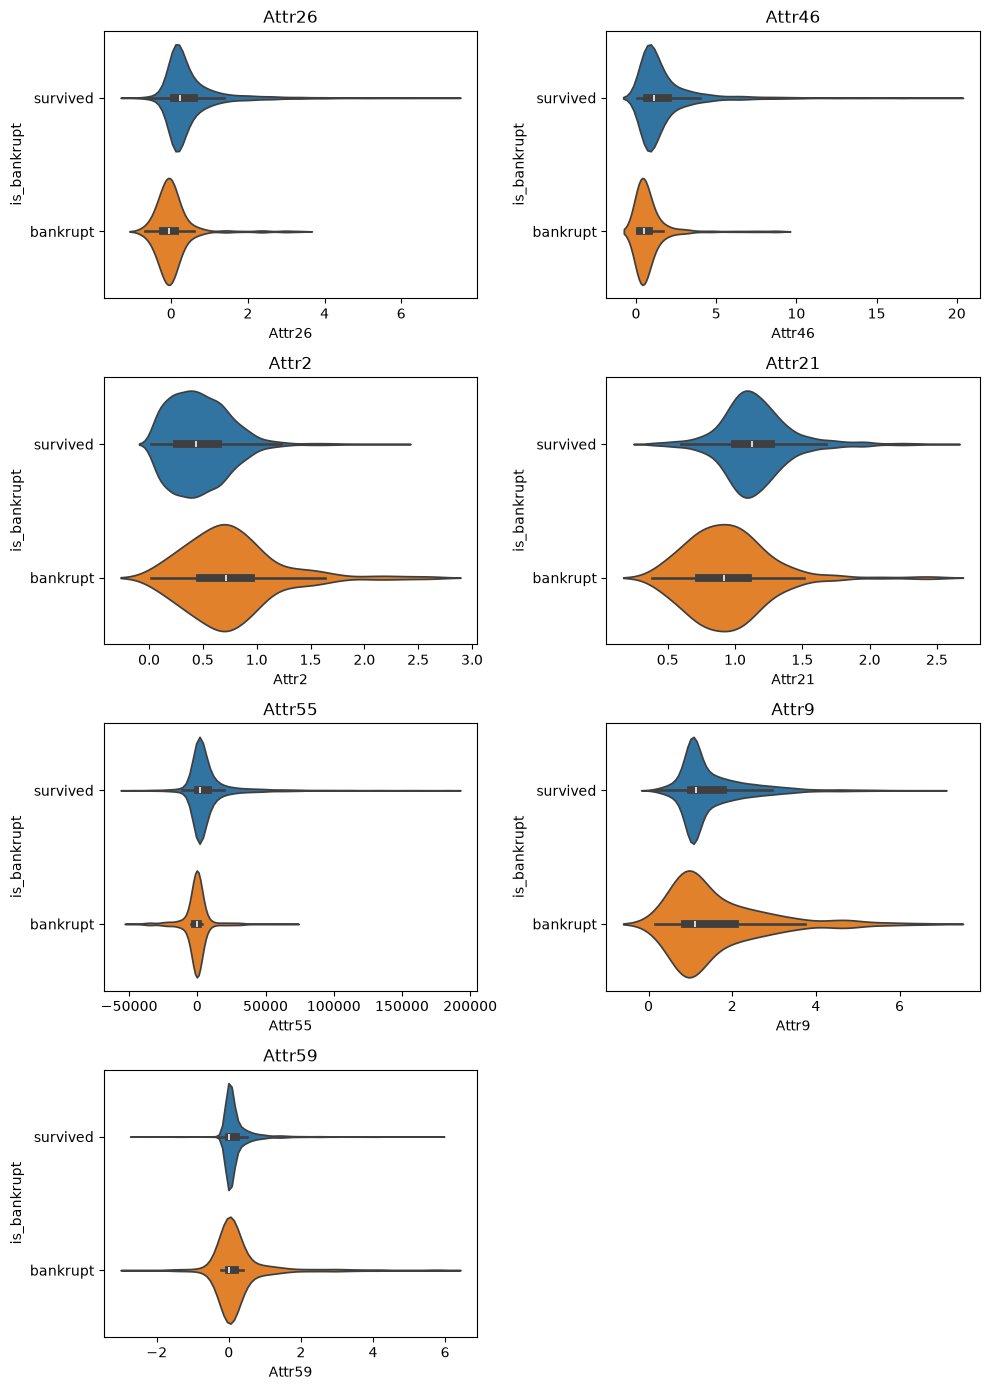

In [13]:
plot_df = X_train[PRIORITY_FEATURES].copy()
# Labels rather than 0/1: readable axis ticks, and hue stops being a numeric scale.
plot_df[TARGET_COL] = y_train.map({0: "survived", 1: "bankrupt"})

fig, axes = plt.subplots(4, 2, figsize=(10, 14))

for ax, col in zip(axes.flatten(), PRIORITY_FEATURES):
    lo, hi = plot_df[col].quantile([0.01, 0.99])
    subset = plot_df[plot_df[col].between(lo, hi)]
    sns.violinplot(
        data=subset, x=col, y=TARGET_COL, hue=TARGET_COL, ax=ax, legend=False
    )
    ax.set_title(col)

axes.flatten()[7].axis("off")  # seven features, eight cells
fig.tight_layout()

**The last two panels are wrong and are kept as an illustration.** `Attr59` has a point mass at zero
— around half its values are exactly 0 — and KDE cannot render a point mass: it smears the spike
into a hump and invents density to the left of zero where no observations exist. `Attr55` is an
absolute złoty amount spanning orders of magnitude, so its mass collapses into a spike. Both are
re-plotted in section 5.

**The other five.**

- **`Attr2`** (total liabilities / total assets, AUC 0.720) — the only one where the bankrupt peak
  sits to the *right*. Survivors peak around 0.4–0.5 and thin out by 1.0; bankrupts peak near 0.7
  with visible mass beyond 1.0, i.e. liabilities exceeding assets — negative equity. Survivors
  barely reach that zone.
- **`Attr26`** ((net profit + depreciation) / total liabilities) — bankrupt mass sits at and below
  zero, survivors are tightly packed around 0.2–0.5. Below zero means the loss exceeds depreciation:
  no cash generation against the debt at all.
- **`Attr46`** (quick ratio) — survivors peak near 1.0 with a long right tail, bankrupts near 0.5.
  Below 1.0 the liquid assets do not cover short-term liabilities without selling inventory.
- **`Attr21`** (sales growth) — medians nearly coincide at ~1.0; what differs is spread. The
  bankrupt distribution is wider on both sides, so the signal is instability of revenue rather than
  a lower growth rate.
- **`Attr9`** (asset turnover, Altman X5) — same pattern, more pronounced. Survivors form a narrow
  spike at 1.0–1.5; bankrupts are flat and stretched from 0 to 4, both idle assets and very thin
  asset bases. Both extremes are unhealthy, in opposite directions.

**Why `Attr9` scores 0.469.** ROC-AUC measures monotone ordering — "higher value, higher risk". Here
the relationship is non-monotone: bad on the left *and* on the right. A metric built on pairwise
ordering is blind to a difference in dispersion, and so is logistic regression, which can only add a
constant to the logit per unit of the feature. A tree splits the axis into intervals and can assign
different risk to each. Concrete expectation for the model comparison: `Attr9` should carry a
near-zero coefficient in the linear model and non-zero importance in LightGBM.

## 5. Features that do not fit a linear axis

Rather than judging by eye, compactness measures how much of the visible axis the bulk of the data
occupies: the interquartile range divided by the 1–99% span. A normal distribution gives ≈ 0.29 and
a uniform one 0.5, so anything below ~0.10 is a spike rather than a shape.

In [14]:
for col in PRIORITY_FEATURES:
    q01, q25, q75, q99 = plot_df[col].quantile([0.01, 0.25, 0.75, 0.99])
    print(f"{col}: {(q75 - q25) / (q99 - q01):.3f}")

Attr26: 0.063
Attr46: 0.068
Attr2: 0.156
Attr21: 0.125
Attr55: 0.033
Attr9: 0.122
Attr59: 0.024


In [15]:
# Starting point for linthresh: the median absolute value, i.e. the typical distance from zero.
# Absolute because the linear band of symlog is symmetric; median because the mean is dragged
# by the very tails being tamed.
print(plot_df["Attr59"].abs().median())
print(plot_df["Attr55"].abs().median())

0.011664
2914.5


ECDF instead of a histogram or violin: it has no bandwidth and no bins, so a point mass shows up as
an honest vertical jump and nothing is invented between observations. The y-axis is the cumulative
share of rows at or below the x value, which makes the **vertical gap between the two curves** the
quantity to read — where the curves touch, the feature does not separate the classes.

`linthresh` values are rounded from the medians above; they are a display choice, not a property of
the data.

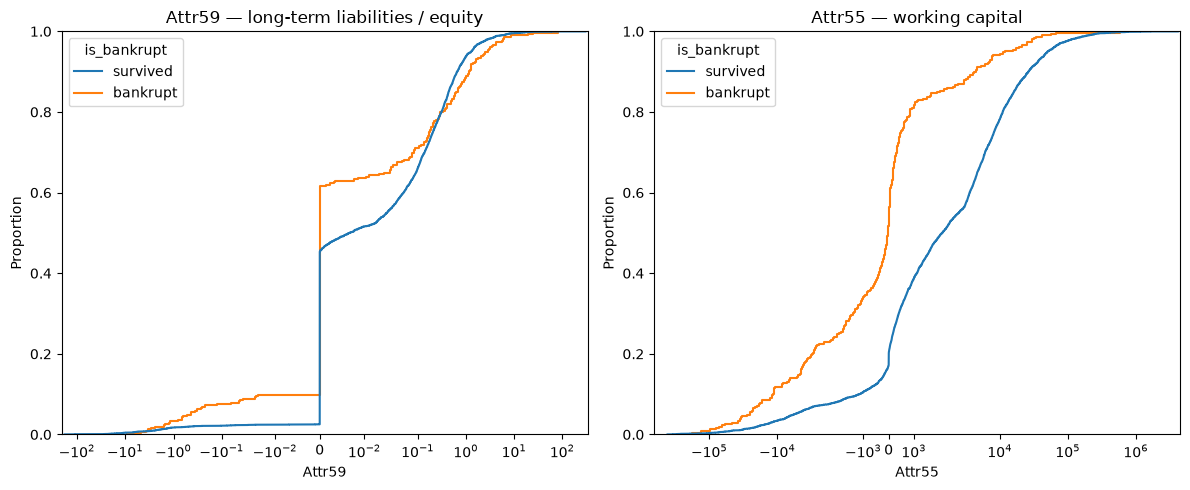

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.ecdfplot(data=plot_df, x="Attr59", hue=TARGET_COL, ax=axes[0])
axes[0].set_xscale("symlog", linthresh=0.012)
axes[0].set_title("Attr59 — long-term liabilities / equity")

sns.ecdfplot(data=plot_df, x="Attr55", hue=TARGET_COL, ax=axes[1])
axes[1].set_xscale("symlog", linthresh=3000)
axes[1].set_title("Attr55 — working capital")

fig.tight_layout()

**`Attr59`.** The vertical jump at zero runs 0.10 → 0.62 for bankrupts and 0.026 → 0.46 for
survivors: 52% of bankrupts and 43% of survivors have no long-term debt at all. More interesting is
what happens to the left — 10% of bankrupts sit in the negative zone against 2.6% of survivors.
`Attr59` is long-term liabilities over equity, so a negative value means **negative equity**:
liabilities exceed assets and the company is technically insolvent. Nearly a fourfold difference,
concentrated in a narrow band of the feature.

To the right of 1.0 the two curves converge, which is the other half of the finding: the actual
magnitude of the leverage ratio separates nothing. All the information is at zero and below. That
explains the 0.432 ROC-AUC — a strong local effect averaged together with a region carrying no
signal, plus the mass of ties from the zeros.

Candidate feature: `has_negative_equity`, to be tested on CV.

**`Attr55`.** The gap between the curves is large across the whole axis and peaks just above zero,
around 10³: at that point 80% of bankrupts are accumulated against 45% of survivors. Working capital
is an absolute złoty amount, so this is firm size acting as a predictor — bigger companies fail less
often — and the split works best near the boundary between negative and modestly positive working
capital. Also visible: 15% of survivors and 25% of bankrupts have negative working capital, a fact
the violin panel hid entirely.

## 6. Tail weight across all features

Compactness and the ratio of the largest absolute value to the 99th percentile, computed for all 64
features rather than the seven above. This is what the choice of scaler for the linear branch rests
on: the boosting branch splits on order and is indifferent to the magnitudes here.

In [17]:
rows = []
for col in X_train.columns:
    s = X_train[col].dropna()
    q01, q25, q75, q99 = s.quantile([0.01, 0.25, 0.75, 0.99])
    abs_s = s.abs()
    rows.append(
        {
            "feature": col,
            "compactness": (q75 - q25) / (q99 - q01),
            # On absolute values so that a negative q99 cannot flip the sign of the ratio.
            # Reads as "the most extreme deviation from zero, in units of the typical extreme".
            "max_over_q99": abs_s.max() / abs_s.quantile(0.99),
        }
    )

outliers = pd.DataFrame(rows).set_index("feature")
print(outliers.sort_values("compactness").head(20))

         compactness  max_over_q99
feature                           
Attr27      0.000771     70.452184
Attr37      0.008363     25.660833
Attr45      0.016593     45.325577
Attr41      0.017424    332.229262
Attr60      0.019299     39.241529
Attr64      0.019777    438.221758
Attr54      0.020844    232.174841
Attr28      0.021665    234.384805
Attr53      0.022181    232.174841
Attr59      0.024240     36.217712
Attr55      0.032530     19.055728
Attr6       0.032853    201.434458
Attr15      0.033032    166.145414
Attr57      0.035704    173.786335
Attr40      0.040181     37.436618
Attr12      0.061406    109.657226
Attr26      0.062546     26.288462
Attr5       0.063728    693.570108
Attr23      0.064651    194.502411
Attr8       0.064678     85.330636


**The tails are extreme.** `Attr5` reaches 694× its own 99th percentile, `Attr64` 438×, `Attr41`
332×. Over twenty features have compactness below 0.07, so the priority seven were not unusual —
this is what financial ratios look like when the denominator can approach zero.

**Why trimming at a quantile does not fix it.** Look at `Attr27` in section 2: q95 = 114, q99 = 5259,
max = 565 940, against a median of 0.97. Clipping at the 99th percentile still leaves a value five
thousand times the median; clipping at the 95th throws away 10% of the data and still leaves 114.
There is no quantile that both keeps the data and tames the tail.

**Linear branch:** `QuantileTransformer` rather than winsorising. It replaces values by their ranks,
so tails of any weight disappear by construction and no cut-off has to be chosen — and choosing 64
separate cut-offs by eye on the training data would be a form of snooping. The cost is
interpretability: coefficients are no longer expressed in units of a financial ratio. It is a fitted
transformation (the quantiles come from the data), so it belongs inside the `Pipeline`, otherwise
cross-validation folds leak into it.

**Boosting branch:** nothing. A tree splits on order, and the threshold "Attr5 > 12" partitions the
rows identically whether the maximum is 500 or 500 000. Scaling and monotone transforms are wasted
work here.

## 7. Correlation structure

Spearman rather than Pearson: with `max_over_q99` reaching several hundred, a single extreme row
shared by two features would drive a linear coefficient on its own. Ranks make the coefficient
insensitive to how far out the outlier sits and catch any monotone relationship, not only a
straight line.

64 coefficients are built from roughly fifteen raw balance-sheet quantities, so blocks of
near-duplicates are expected. `clustermap` reorders rows and columns so those blocks become visible;
in `Attr1..Attr64` order they are scattered.

Note that `corr` computes each cell pairwise on the rows where both features exist, so cells
involving `Attr37` rest on a different subset than the rest of the matrix.

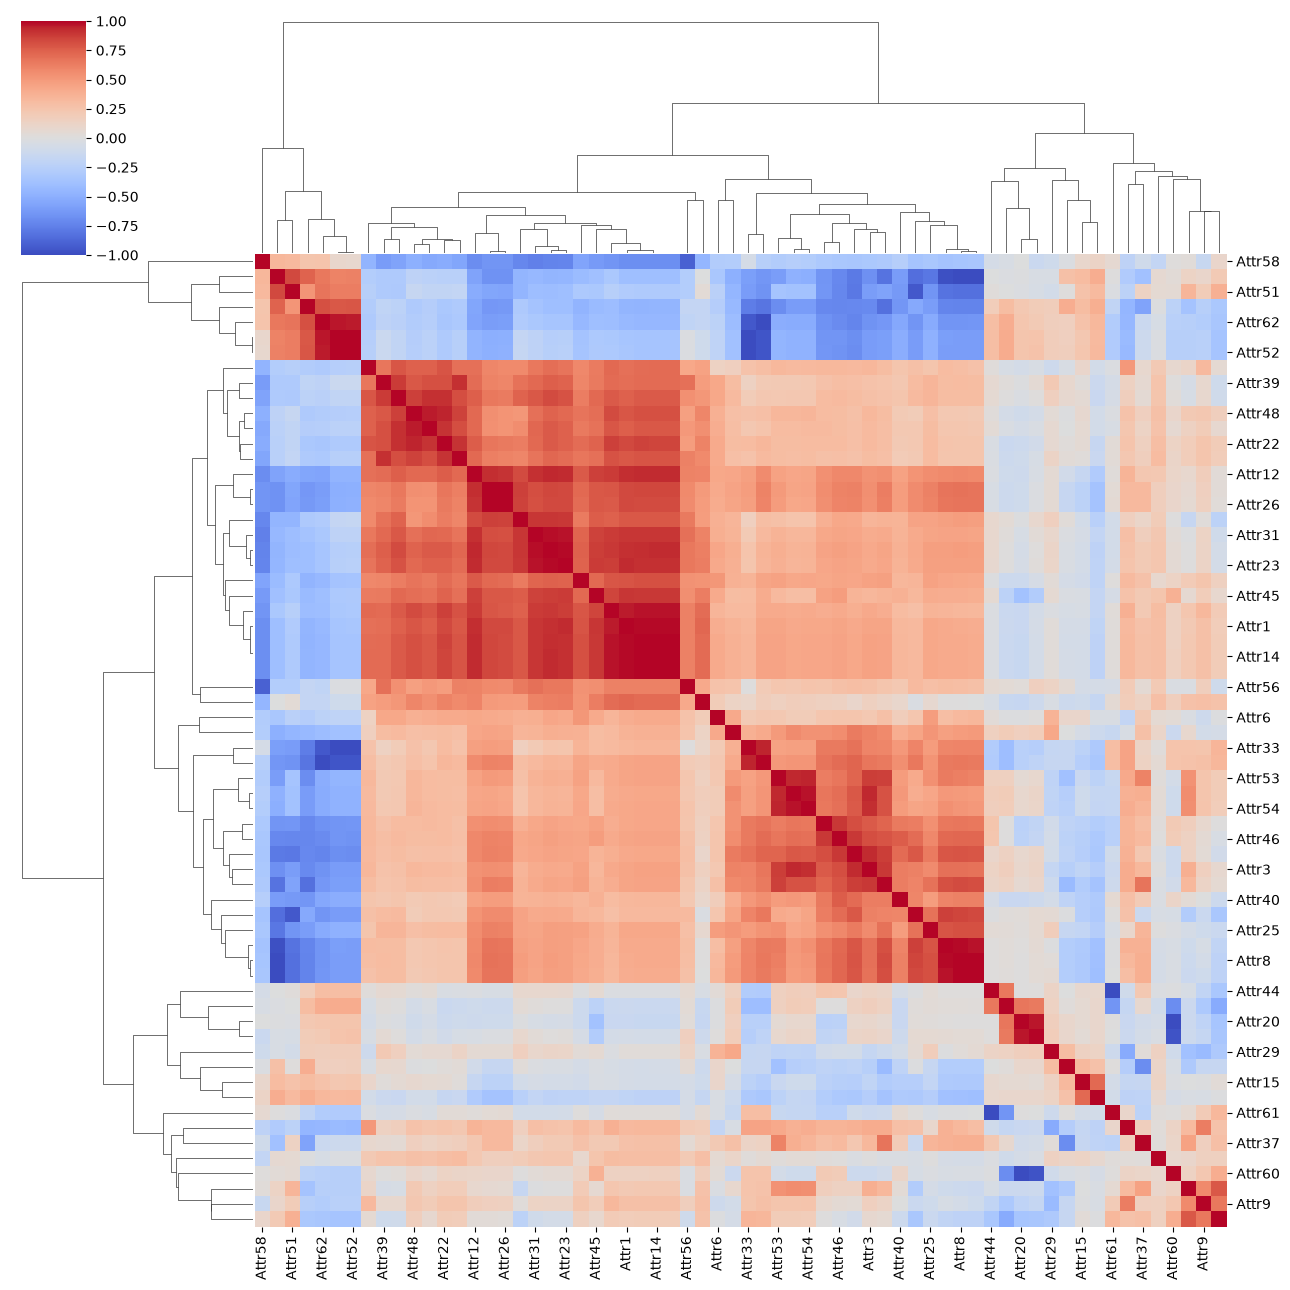

In [18]:
corr = X_train.corr(method="spearman")

# center=0 keeps zero correlation white; without it the colour scale shifts and
# weak relationships read as strong ones.
sns.clustermap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, figsize=(13, 13))

In [19]:
# The matrix is symmetric, so only the upper triangle is kept — otherwise every
# pair appears twice and the diagonal of ones tops the list.
upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.abs().where(upper).stack().sort_values(ascending=False)

print("pairs above 0.99:", (pairs > 0.99).sum())
print("pairs above 0.95:", (pairs > 0.95).sum())
print(pairs.head(25))

pairs above 0.99: 13
pairs above 0.95: 34
Attr20  Attr60    0.999997
Attr14  Attr18    0.999940
Attr7   Attr14    0.999615
        Attr18    0.999250
Attr44  Attr61    0.999170
Attr62  Attr63    0.998630
Attr2   Attr17    0.998448
Attr33  Attr52    0.998328
Attr32  Attr52    0.996661
        Attr33    0.994857
Attr8   Attr17    0.994475
Attr2   Attr8     0.993255
Attr16  Attr26    0.992738
Attr8   Attr10    0.989299
Attr1   Attr7     0.988007
        Attr14    0.987625
        Attr18    0.987266
Attr19  Attr23    0.986424
        Attr31    0.979196
Attr2   Attr10    0.977312
Attr28  Attr54    0.976545
Attr10  Attr17    0.975922
Attr23  Attr31    0.970908
Attr7   Attr11    0.970005
Attr11  Attr14    0.969568
dtype: float64


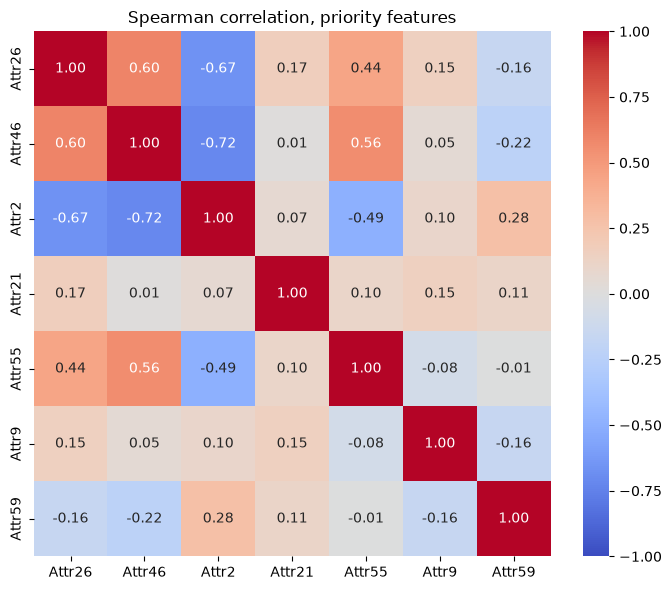

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    X_train[PRIORITY_FEATURES].corr(method="spearman"),
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    ax=ax,
)
ax.set_title("Spearman correlation, priority features")
fig.tight_layout()

**Thirteen pairs above 0.99 and thirty-four above 0.95 — arithmetic rather than a discovery.** `Attr7`, `Attr14` and
`Attr18` form a triple correlated at 0.999 — EBIT, gross profit and gross profit plus interest, all
over total assets, differing only by interest, which is small relative to profit for most companies.
`Attr20` and `Attr60` are reciprocals of each other (inventory/sales vs sales/inventory), as are
`Attr2` and `Attr17`; Spearman sees a perfect monotone relationship in both. 64 ratios built from
roughly fifteen raw quantities inevitably include restated versions of the same thing.

The clustermap shows the structure: one large profitability block in the centre (the sixteen from
section 1), a cost-and-short-term-liability block correlating negatively with it, and a loose group on the
right — turnover, size, `Attr37` — only weakly connected to anything. Profitability and turnover
live in different parts of the matrix.

**Linear branch.** Correlations at 0.999 make the design matrix near-singular: weights split
arbitrarily between duplicates and swing from fold to fold. L2 regularisation, on by default in
`LogisticRegression`, keeps predictions stable by spreading the weight across the block rather than
picking one. Dropping duplicates above a fixed threshold is the alternative; it is a fitted step
(correlations come from the training data) and belongs in the `Pipeline`. Plan: regularisation as
the default, drop-by-threshold tested against it on CV — if the difference is smaller than the sum
of the standard deviations, keep the simpler option.

**Boosting branch.** Indifferent — a tree picks one of two identical features and ignores the other.

**Consequence for reading feature importance, which matters more than either.** With features correlated at 0.999 the
model distributes importance among them arbitrarily; whichever happens to be picked first looks more
important. "EBIT/assets matters more than gross profit/assets" would be an artefact of tree
construction, not a property of the data. Feature importance has to be read **by block**, not by
individual feature — and it says nothing about causation in any case.

**The priority set holds up.** In the 7×7 matrix the strongest pair is `Attr46`↔`Attr2` at −0.72
(liquidity against leverage, expected), `Attr21` is nearly independent of everything (|ρ| ≤ 0.17),
`Attr59` reaches 0.28. Selecting one representative per economic family did what it was meant to do:
the seven panels in section 4 are seven different views, not one view repeated.

## 8. Decisions carried forward

| Decision | Evidence |
|---|---|
| All work in this notebook runs on the training split | Trimming points, feature choices and transforms are decided after seeing the data |
| Missingness indicators for 7 columns, via `ColumnTransformer` | 49 columns have gaps; 1% threshold leaves 11; inventory and fixed-asset blocks collapse to one each |
| Drop the `has_no_long_term_debt` candidate | The `Attr37` indicator encodes the same state |
| **Exclude the `Attr21` missingness indicator** | 78 of 80 flagged rows are bankrupt; uniformly elevated missingness suggests collection artefact, not signal |
| Linear branch: `QuantileTransformer` inside the `Pipeline` | `max/q99` up to 694; no quantile cut-off both keeps the data and tames the tail |
| Linear branch: rely on L2, test correlation-based dropping on CV | 13 pairs above 0.99 and 34 above 0.95; several are reciprocals of each other |
| Boosting branch: no scaling, no trimming, NaN untouched | Trees split on order; magnitudes and gaps are irrelevant |
| Read feature importance by block, never per feature | Importance splits arbitrarily among features correlated at 0.999 |
| Report precision@top-k alongside PR-AUC | Concentrated subgroup effects (47.9% in 96 rows) barely move an averaged ranking metric |
| CV candidates: `has_negative_equity`, "debt but no interest paid" | 10% vs 2.6% of classes below zero in `Attr59`; 47.9% vs 7.0% base rate |
| Expect `Attr9` weak in LogReg, non-zero in LightGBM | Classes differ in dispersion, not location — a non-monotone relationship |
| README limitation: `Attr21` missingness is a possible collection artefact | Cannot be resolved without metadata on how the dataset was assembled |